# Assignment 1: Myanmar POS Tagger with CRF (myPOS v3.0)

### Steps
1. Install packages & download myPOS train / open-test data  
2. Parse corpus (`word/tag`, nopipe compound words)  
3. Extract **baseline** and **improved** features  
4. Feature ablation (baseline vs improved)  
5. Light hyperparameter tuning (`c1`, `c2`)  
6. Train final CRF & evaluate on `otest.1k`  
7. Confusion matrix + error analysis  
8. Transition inspection & inference demo

### Tagset (15 tags)
`abb, adj, adv, conj, fw, int, n, num, part, ppm, pron, punc, sb, tn, v`

## 1. Install & imports

In [1]:
%pip install -q sklearn-crfsuite python-crfsuite scikit-learn tqdm matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import time
from collections import Counter
from pathlib import Path
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn_crfsuite
from sklearn.metrics import confusion_matrix
from sklearn_crfsuite import metrics
from tqdm.auto import tqdm

## 2. Download myPOS v3.0 data

- Train: `train.mypos-ver3.txt` (~42,196 sentences)  
- Open test: `otest.1k.txt` (1,000 sentences)  

Format: `word/tag word/tag ...`  
Compound words use `|` (e.g. `အလုပ်/n|အားလပ်ရက်/n`).  
Official CRF pipeline replaces `|` with space (**nopipe**).

In [4]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

BASE = 'https://raw.githubusercontent.com/ye-kyaw-thu/myPOS/master/corpus-ver-3.0/corpus'
FILES = {
    'train.mypos-ver3.txt': f'{BASE}/train.mypos-ver3.txt',
    'otest.1k.txt': f'{BASE}/otest.1k.txt',
}

for name, url in FILES.items():
    path = DATA_DIR / name
    if not path.exists():
        print(f'Downloading {name} ...')
        urlretrieve(url, path)
    else:
        print(f'Found {path}')

TRAIN_PATH = DATA_DIR / 'train.mypos-ver3.txt'
TEST_PATH = DATA_DIR / 'otest.1k.txt'

MYPOS_TAGS = [
    'abb', 'adj', 'adv', 'conj', 'fw', 'int', 'n', 'num',
    'part', 'ppm', 'pron', 'punc', 'sb', 'tn', 'v'
]

In [5]:
def parse_sentence(line: str):
    """Parse myPOS line; replace '|' with space (nopipe)."""
    line = line.strip().replace('|', ' ')
    if not line:
        return []
    tokens = []
    for tok in line.split():
        if '/' not in tok:
            continue
        word, tag = tok.rsplit('/', 1)
        if word and tag:
            tokens.append((word, tag))
    return tokens


def load_corpus(path: Path):
    sents = []
    with path.open(encoding='utf-8') as f:
        for line in f:
            sent = parse_sentence(line)
            if sent:
                sents.append(sent)
    return sents


train_sents = load_corpus(TRAIN_PATH)
test_sents = load_corpus(TEST_PATH)

print(f'Train sentences: {len(train_sents):,}')
print(f'Test  sentences: {len(test_sents):,}')
print(f'Train tokens   : {sum(len(s) for s in train_sents):,}')
print(f'Test  tokens   : {sum(len(s) for s in test_sents):,}')
print('\nExample (first 10 tokens):')
print(train_sents[0][:10])

Train sentences: 42,196
Test  sentences: 1,000
Train tokens   : 551,049
Test  tokens   : 13,468

Example (first 10 tokens):
[('၁၉၆၂', 'num'), ('ခုနှစ်', 'n'), ('ခန့်မှန်း', 'v'), ('သန်းခေါင်စာရင်း', 'n'), ('အရ', 'ppm'), ('လူဦးရေ', 'n'), ('၁၁၅၉၃၁', 'num'), ('ယောက်', 'part'), ('ရှိ', 'v'), ('သည်', 'ppm')]


In [6]:
tag_counts = Counter(tag for s in train_sents for _, tag in s)
print('Train tag distribution:')
for tag, cnt in sorted(tag_counts.items(), key=lambda x: -x[1]):
    print(f'  {tag:6s} {cnt:,}')

labels = [t for t in MYPOS_TAGS if t in tag_counts] + [
    t for t in tag_counts if t not in MYPOS_TAGS
]

Train tag distribution:
  part   132,078
  n      119,892
  ppm    84,430
  v      82,070
  punc   52,838
  pron   19,937
  conj   17,397
  adj    16,064
  adv    10,449
  num    5,787
  tn     5,702
  fw     3,141
  int    647
  abb    348
  sb     269


## 3. Feature extraction

### Baseline (CRF_Tutorial / class-style)
Word identity in a ±2 window + BOS/EOS.

### Improved
Baseline + character prefixes/suffixes, length, digit flag, **word-shape** (Burmese / Latin / digit / punct), and local bigrams.  
Shape/affix features help on **unseen words** (esp. `fw`, `num`, `tn`).

In [7]:
LATIN = re.compile(r'[A-Za-z]')
DIGIT = re.compile(r'[0-9၀-၉]')
PUNCT = re.compile(r'^[\W_]+$', re.UNICODE)


def word_shape(word: str) -> str:
    if PUNCT.match(word):
        return 'punct'
    if LATIN.search(word):
        return 'latin_mixed' if DIGIT.search(word) else 'latin'
    if DIGIT.search(word):
        return 'has_digit'
    return 'burmese'


def baseline_features(sent, i):
    """Word identities in a +-2 window (tutorial / class template)."""
    word = sent[i][0]
    features = {
        'bias': 1.0,
        'word': word,
    }
    if i > 0:
        features['-1:word'] = sent[i - 1][0]
    else:
        features['BOS'] = True
    if i < len(sent) - 1:
        features['+1:word'] = sent[i + 1][0]
    else:
        features['EOS'] = True
    if i > 1:
        features['-2:word'] = sent[i - 2][0]
    if i < len(sent) - 2:
        features['+2:word'] = sent[i + 2][0]
    return features


def improved_features(sent, i):
    """Baseline + affix / shape / length features for unseen words."""
    word = sent[i][0]
    features = baseline_features(sent, i)
    features.update({
        'word[-1:]': word[-1:],
        'word[-2:]': word[-2:] if len(word) >= 2 else word,
        'word[-3:]': word[-3:] if len(word) >= 3 else word,
        'word[:1]': word[:1],
        'word[:2]': word[:2] if len(word) >= 2 else word,
        'word[:3]': word[:3] if len(word) >= 3 else word,
        'word.isdigit': word.isdigit(),
        'word.length': min(len(word), 10),
        'shape': word_shape(word),
    })
    if i > 0:
        w1 = sent[i - 1][0]
        features['-1:shape'] = word_shape(w1)
        features['-1:word[-2:]'] = w1[-2:] if len(w1) >= 2 else w1
        features['bigram-1'] = f'{w1}|{word}'
    if i < len(sent) - 1:
        w1 = sent[i + 1][0]
        features['+1:shape'] = word_shape(w1)
        features['+1:word[-2:]'] = w1[-2:] if len(w1) >= 2 else w1
        features['bigram+1'] = f'{word}|{w1}'
    return features


def sent2features(sent, feat_fn):
    return [feat_fn(sent, i) for i in range(len(sent))]


def sent2labels(sent):
    return [tag for _, tag in sent]


def sent2tokens(sent):
    return [w for w, _ in sent]


print('Shape examples:')
for w in ['ကျွန်တော်', 'COVID', '၂၀၂၆', '123', '။', '%']:
    print(f'  {w:12s} -> {word_shape(w)}')
print('\nImproved feature preview:')
improved_features(train_sents[0], 0)

Shape examples:
  ကျွန်တော်    -> burmese
  COVID        -> latin
  ၂၀၂၆         -> has_digit
  123          -> has_digit
  ။            -> punct
  %            -> punct

Improved feature preview:


{'bias': 1.0,
 'word': '၁၉၆၂',
 'BOS': True,
 '+1:word': 'ခုနှစ်',
 '+2:word': 'ခန့်မှန်း',
 'word[-1:]': '၂',
 'word[-2:]': '၆၂',
 'word[-3:]': '၉၆၂',
 'word[:1]': '၁',
 'word[:2]': '၁၉',
 'word[:3]': '၁၉၆',
 'word.isdigit': True,
 'word.length': 4,
 'shape': 'has_digit',
 '+1:shape': 'burmese',
 '+1:word[-2:]': 'စ်',
 'bigram+1': '၁၉၆၂|ခုနှစ်'}

## 4. Helpers: train / evaluate

In [8]:
def featurize(sents, feat_fn):
    X = [sent2features(s, feat_fn) for s in tqdm(sents, leave=False)]
    y = [sent2labels(s) for s in sents]
    return X, y


def token_accuracy(y_true, y_pred):
    yt = [lab for seq in y_true for lab in seq]
    yp = [lab for seq in y_pred for lab in seq]
    return sum(a == b for a, b in zip(yt, yp)) / len(yt)


def sentence_accuracy(y_true, y_pred):
    return sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)


def eval_model(model, X, y, label_list, title=''):
    y_pred = model.predict(X)
    acc = token_accuracy(y, y_pred)
    sent_acc = sentence_accuracy(y, y_pred)
    f1_micro = metrics.flat_f1_score(y, y_pred, average='micro', labels=label_list)
    f1_macro = metrics.flat_f1_score(y, y_pred, average='macro', labels=label_list)
    f1_weighted = metrics.flat_f1_score(y, y_pred, average='weighted', labels=label_list)
    if title:
        print(title)
    print(f'  Token accuracy : {acc * 100:.2f}%')
    print(f'  Sentence acc.  : {sent_acc * 100:.2f}%')
    print(f'  F1 (micro)     : {f1_micro * 100:.2f}%')
    print(f'  F1 (macro)     : {f1_macro * 100:.2f}%')
    print(f'  F1 (weighted)  : {f1_weighted * 100:.2f}%')
    return {
        'y_pred': y_pred,
        'acc': acc,
        'sent_acc': sent_acc,
        'f1_micro': f1_micro,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
    }


def train_crf(X, y, c1=0.1, c2=0.1, max_iterations=100):
    crf = sklearn_crfsuite.CRF(
        algorithm='lbfgs',
        c1=c1,
        c2=c2,
        max_iterations=max_iterations,
        all_possible_transitions=True,
    )
    t0 = time.time()
    crf.fit(X, y)
    print(f'  trained in {time.time() - t0:.1f}s (c1={c1}, c2={c2})')
    return crf

## 5. Feature ablation (baseline vs improved)

Train both feature sets on the full training corpus and compare on official `otest.1k`.

In [9]:
y_test = [sent2labels(s) for s in test_sents]

print('Featurizing (baseline)...')
X_train_base, y_train = featurize(train_sents, baseline_features)
X_test_base, _ = featurize(test_sents, baseline_features)

print('Training baseline CRF...')
crf_base = train_crf(X_train_base, y_train, c1=0.1, c2=0.1)
base_res = eval_model(crf_base, X_test_base, y_test, labels, title='=== Baseline on otest.1k ===')

Featurizing (baseline)...


  0%|          | 0/42196 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Training baseline CRF...
  trained in 47.2s (c1=0.1, c2=0.1)
=== Baseline on otest.1k ===
  Token accuracy : 95.58%
  Sentence acc.  : 61.80%
  F1 (micro)     : 95.58%
  F1 (macro)     : 91.86%
  F1 (weighted)  : 95.52%


In [10]:
print('Featurizing (improved)...')
X_train_imp, _ = featurize(train_sents, improved_features)
X_test_imp, _ = featurize(test_sents, improved_features)

print('Training improved CRF...')
crf_imp = train_crf(X_train_imp, y_train, c1=0.1, c2=0.1)
imp_res = eval_model(crf_imp, X_test_imp, y_test, labels, title='=== Improved on otest.1k ===')

print('\n=== Ablation summary ===')
print(f"{'metric':20s} {'baseline':>10s} {'improved':>10s} {'delta':>10s}")
for key, name in [
    ('acc', 'token acc'),
    ('sent_acc', 'sentence acc'),
    ('f1_macro', 'F1 macro'),
    ('f1_weighted', 'F1 weighted'),
]:
    b, i = base_res[key], imp_res[key]
    print(f'{name:20s} {b*100:9.2f}% {i*100:9.2f}% {(i-b)*100:+9.2f}%')

Featurizing (improved)...


  0%|          | 0/42196 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Training improved CRF...
  trained in 99.5s (c1=0.1, c2=0.1)
=== Improved on otest.1k ===
  Token accuracy : 96.73%
  Sentence acc.  : 69.30%
  F1 (micro)     : 96.73%
  F1 (macro)     : 95.65%
  F1 (weighted)  : 96.72%

=== Ablation summary ===
metric                 baseline   improved      delta
token acc                95.58%     96.73%     +1.15%
sentence acc             61.80%     69.30%     +7.50%
F1 macro                 91.86%     95.65%     +3.79%
F1 weighted              95.52%     96.72%     +1.20%


## 6. Hyperparameter tuning (`c1`, `c2`)

Hold out the last 2,000 training sentences as **dev**.  
Grid-search a few Elastic-Net settings with **improved** features, then retrain on the full train set with the best pair.

In [11]:
DEV_N = 2000
tune_train_sents = train_sents[:-DEV_N]
dev_sents = train_sents[-DEV_N:]

print(f'Tune-train: {len(tune_train_sents):,} | Dev: {len(dev_sents):,}')
X_tune_train, y_tune_train = featurize(tune_train_sents, improved_features)
X_dev, y_dev = featurize(dev_sents, improved_features)

param_grid = [
    (0.01, 0.1),
    (0.1, 0.1),
    (0.1, 0.01),
    (0.5, 0.1),
    (0.1, 0.5),
]

tune_rows = []
print('\n=== Hyperparameter search (dev set) ===')
for c1, c2 in param_grid:
    print(f'\nTrying c1={c1}, c2={c2}')
    m = train_crf(X_tune_train, y_tune_train, c1=c1, c2=c2, max_iterations=80)
    res = eval_model(m, X_dev, y_dev, labels)
    tune_rows.append({'c1': c1, 'c2': c2, **{k: res[k] for k in ('acc', 'f1_macro', 'f1_weighted')}})

best = max(tune_rows, key=lambda r: r['f1_macro'])
print('\n=== Tuning results ===')
print(f"{'c1':>6} {'c2':>6} {'acc':>10} {'f1_macro':>10} {'f1_w':>10}")
for r in tune_rows:
    mark = ' <-- best' if r is best else ''
    print(f"{r['c1']:6.2f} {r['c2']:6.2f} {r['acc']*100:9.2f}% {r['f1_macro']*100:9.2f}% {r['f1_weighted']*100:9.2f}%{mark}")

BEST_C1, BEST_C2 = best['c1'], best['c2']
print(f'\nSelected: c1={BEST_C1}, c2={BEST_C2}')

Tune-train: 40,196 | Dev: 2,000


  0%|          | 0/40196 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]


=== Hyperparameter search (dev set) ===

Trying c1=0.01, c2=0.1
  trained in 85.8s (c1=0.01, c2=0.1)
  Token accuracy : 96.63%
  Sentence acc.  : 68.50%
  F1 (micro)     : 96.63%
  F1 (macro)     : 94.80%
  F1 (weighted)  : 96.61%

Trying c1=0.1, c2=0.1
  trained in 90.1s (c1=0.1, c2=0.1)
  Token accuracy : 96.73%
  Sentence acc.  : 69.30%
  F1 (micro)     : 96.73%
  F1 (macro)     : 95.30%
  F1 (weighted)  : 96.72%

Trying c1=0.1, c2=0.01
  trained in 83.5s (c1=0.1, c2=0.01)
  Token accuracy : 96.60%
  Sentence acc.  : 68.20%
  F1 (micro)     : 96.60%
  F1 (macro)     : 94.91%
  F1 (weighted)  : 96.59%

Trying c1=0.5, c2=0.1
  trained in 82.3s (c1=0.5, c2=0.1)
  Token accuracy : 96.56%
  Sentence acc.  : 67.95%
  F1 (micro)     : 96.56%
  F1 (macro)     : 94.86%
  F1 (weighted)  : 96.54%

Trying c1=0.1, c2=0.5
  trained in 83.9s (c1=0.1, c2=0.5)
  Token accuracy : 96.64%
  Sentence acc.  : 68.50%
  F1 (micro)     : 96.64%
  F1 (macro)     : 94.43%
  F1 (weighted)  : 96.62%

=== Tunin

## 7. Final model (full train + best hyperparameters)

myPOS v3.0 README reference: official CRF++ open-test F1 ≈ **95.39%**.

In [12]:
print('Training FINAL CRF on full train (improved features)...')
crf = train_crf(X_train_imp, y_train, c1=BEST_C1, c2=BEST_C2, max_iterations=100)
final_res = eval_model(crf, X_test_imp, y_test, labels, title='=== FINAL on otest.1k ===')
y_pred = final_res['y_pred']

print('\nPer-tag classification report:')
print(metrics.flat_classification_report(y_test, y_pred, labels=labels, digits=4))

Training FINAL CRF on full train (improved features)...
  trained in 106.1s (c1=0.1, c2=0.1)
=== FINAL on otest.1k ===
  Token accuracy : 96.73%
  Sentence acc.  : 69.30%
  F1 (micro)     : 96.73%
  F1 (macro)     : 95.65%
  F1 (weighted)  : 96.72%

Per-tag classification report:
              precision    recall  f1-score   support

         abb     1.0000    0.9167    0.9565        12
         adj     0.8912    0.8279    0.8584       366
         adv     0.8840    0.8435    0.8633       262
        conj     0.8889    0.9343    0.9110       411
          fw     0.9667    1.0000    0.9831        87
         int     1.0000    0.9600    0.9796        25
           n     0.9683    0.9770    0.9726      3000
         num     1.0000    0.9871    0.9935       155
        part     0.9716    0.9762    0.9739      3189
         ppm     0.9834    0.9772    0.9803      2060
        pron     0.9684    0.9664    0.9674       476
        punc     1.0000    1.0000    1.0000      1270
          sb    

In [13]:
print('=== Sample predictions ===')
for i in range(3):
    words = sent2tokens(test_sents[i])
    gold = y_test[i]
    pred = y_pred[i]
    print(f'\nSentence {i + 1}:')
    for w, g, p in zip(words, gold, pred):
        mark = 'OK' if g == p else 'X '
        print(f'  [{mark}] {w}\tgold={g}\tpred={p}')

=== Sample predictions ===

Sentence 1:
  [OK] တစ်	gold=tn	pred=tn
  [OK] ကိုက်	gold=n	pred=n
  [OK] ကို	gold=ppm	pred=ppm
  [OK] ဝမ်	gold=n	pred=n
  [X ] ခုနှစ်ထောင်	gold=tn	pred=v
  [OK] ပါ	gold=part	pred=part
  [OK] ။	gold=punc	pred=punc

Sentence 2:
  [OK] မနှစ်	gold=n	pred=n
  [OK] က	gold=ppm	pred=ppm
  [OK] သူ	gold=pron	pred=pron
  [OK] ကျွန်မ	gold=pron	pred=pron
  [OK] ကို	gold=ppm	pred=ppm
  [OK] သင်	gold=v	pred=v
  [OK] ပေး	gold=part	pred=part
  [OK] တယ်	gold=ppm	pred=ppm
  [OK] ။	gold=punc	pred=punc

Sentence 3:
  [OK] ကျွန်တော့်	gold=pron	pred=pron
  [OK] ခုံ	gold=n	pred=n
  [OK] သွား	gold=v	pred=v
  [OK] ရှာ	gold=v	pred=v
  [OK] မလို့	gold=part	pred=part
  [OK] ။	gold=punc	pred=punc


## 8. Confusion matrix

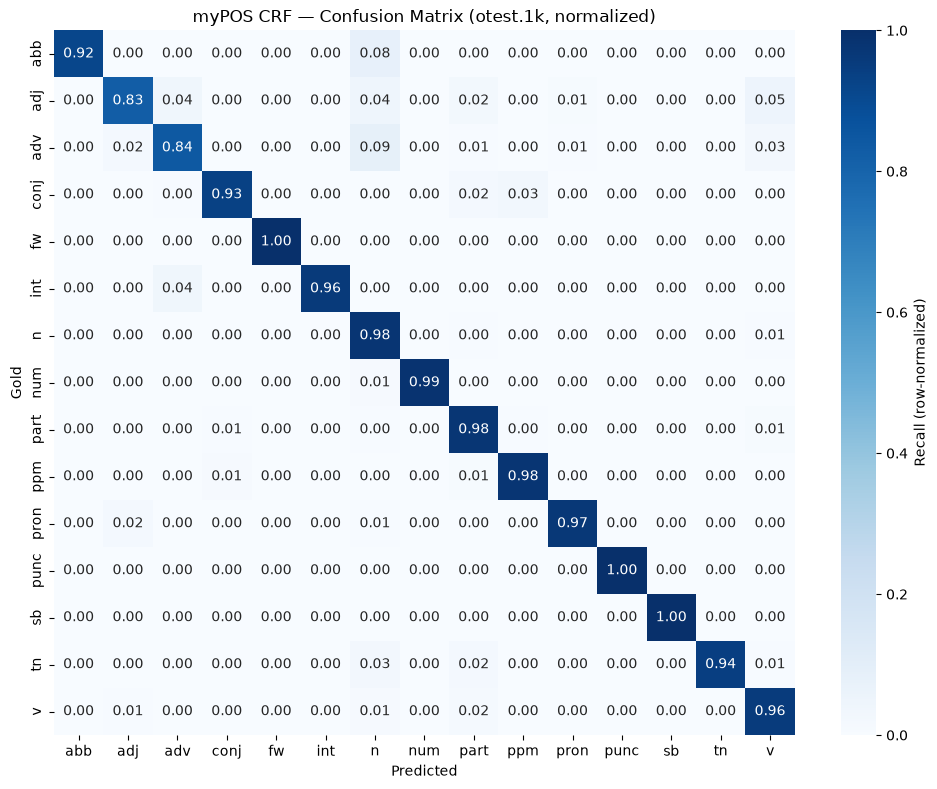

Raw confusion counts (top confusions below in error analysis).


In [14]:
y_true_flat = [lab for seq in y_test for lab in seq]
y_pred_flat = [lab for seq in y_pred for lab in seq]

cm = confusion_matrix(y_true_flat, y_pred_flat, labels=labels)
# row-normalize for readability
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
    cbar_kws={'label': 'Recall (row-normalized)'},
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Gold')
ax.set_title('myPOS CRF — Confusion Matrix (otest.1k, normalized)')
plt.tight_layout()
plt.show()

print('Raw confusion counts (top confusions below in error analysis).')

## 9. Error analysis

Most confused tag pairs and example mis-tagged tokens.

In [15]:
# Top confused pairs (off-diagonal)
pair_counts = Counter()
examples = {}
for sent, gold_seq, pred_seq in zip(test_sents, y_test, y_pred):
    for (w, _), g, p in zip(sent, gold_seq, pred_seq):
        if g != p:
            pair_counts[(g, p)] += 1
            examples.setdefault((g, p), [])
            if len(examples[(g, p)]) < 5:
                examples[(g, p)].append(w)

print(f'Total token errors: {sum(pair_counts.values())} / {len(y_true_flat)}'
      f' ({100 * sum(pair_counts.values()) / len(y_true_flat):.2f}%)')
print('\nTop 15 confused pairs (gold -> pred):')
print(f"{'gold':6s} -> {'pred':6s}  {'count':>5}  examples")
for (g, p), cnt in pair_counts.most_common(15):
    ex = ', '.join(examples[(g, p)][:4])
    print(f'{g:6s} -> {p:6s}  {cnt:5d}  {ex}')

Total token errors: 440 / 13468 (3.27%)

Top 15 confused pairs (gold -> pred):
gold   -> pred    count  examples
v      -> part       37  နေ, လာ, ပြန်, သွား
v      -> n          30  ဝမ်းမြောက်, ဘက်ပြောင်း, မိုးကာ, ပူဇော်
part   -> v          28  လို့, ပေး, ရ, များ
ppm    -> conj       26  နှင့်, နဲ့, နဲ့, နှင့်
n      -> v          23  စိုထိုင်းထိုင်း, မိုးလင်း, မိုးလင်း, ခု
adv    -> n          23  ရှည်ရှည်ဝေးဝေး, ချစ်စရာ, အရေးတကြီး, အများဆုံး
adj    -> v          19  သာယာဝပြော, ထည်ဝါ, တူ, စာတော်
part   -> conj       18  အောင်, အောင်, လျှင်, သမျှ
ppm    -> part       17  များ, ဟာ, မို့, ရဲ့
adj    -> n          16  ရှေ့, အစုံ, အကြီးတန်း, အရှည်ဆုံး
adj    -> adv        15  အရမ်း, ဘယ်လောက်, ပို, အထူး
conj   -> ppm        14  နှင့်, နဲ့, ရအောင်, နဲ့
n      -> part       13  ပုံ, နေ, ကောင်, စောင်
part   -> n          13  သား, ရေ, ကား, စောင်
part   -> ppm        13  ဟာ, အောင်, နှင့်, နဲ့


In [16]:
# Show a few full sentences that contain errors
print('=== Example sentences with errors ===')
shown = 0
for si, (sent, gold_seq, pred_seq) in enumerate(zip(test_sents, y_test, y_pred)):
    if gold_seq == pred_seq:
        continue
    print(f'\nTest sentence #{si}:')
    for (w, _), g, p in zip(sent, gold_seq, pred_seq):
        mark = 'OK' if g == p else 'X '
        print(f'  [{mark}] {w}\tgold={g}\tpred={p}')
    shown += 1
    if shown >= 3:
        break

=== Example sentences with errors ===

Test sentence #0:
  [OK] တစ်	gold=tn	pred=tn
  [OK] ကိုက်	gold=n	pred=n
  [OK] ကို	gold=ppm	pred=ppm
  [OK] ဝမ်	gold=n	pred=n
  [X ] ခုနှစ်ထောင်	gold=tn	pred=v
  [OK] ပါ	gold=part	pred=part
  [OK] ။	gold=punc	pred=punc

Test sentence #5:
  [OK] အေးချမ်း	gold=v	pred=v
  [OK] မှု	gold=part	pred=part
  [OK] နဲ့	gold=conj	pred=conj
  [OK] စည်းကမ်း	gold=n	pred=n
  [OK] ကို	gold=ppm	pred=ppm
  [OK] တည်မြဲ	gold=v	pred=v
  [X ] အောင်	gold=part	pred=conj
  [OK] ထိန်းသိမ်း	gold=v	pred=v
  [OK] သည်	gold=ppm	pred=ppm
  [OK] ။	gold=punc	pred=punc

Test sentence #7:
  [OK] ဘွဲ့	gold=n	pred=n
  [OK] ရ	gold=v	pred=v
  [OK] ရင်	gold=conj	pred=conj
  [X ] ဘာ	gold=n	pred=pron
  [OK] လုပ်	gold=v	pred=v
  [OK] မ	gold=part	pred=part
  [X ] လို့	gold=part	pred=v
  [OK] လဲ	gold=part	pred=part
  [OK] ။	gold=punc	pred=punc


## 10. Learned transitions

In [17]:
print('Top likely transitions:')
for (frm, to), w in Counter(crf.transition_features_).most_common(10):
    print(f'  {frm:6s} -> {to:6s}  {w:8.4f}')

print('\nTop unlikely transitions:')
for (frm, to), w in Counter(crf.transition_features_).most_common()[-10:]:
    print(f'  {frm:6s} -> {to:6s}  {w:8.4f}')

Top likely transitions:
  int    -> int       2.5456
  v      -> part      1.8629
  fw     -> sb        1.6747
  abb    -> abb       1.6242
  num    -> num       1.1878
  fw     -> fw        1.1417
  pron   -> ppm       1.0635
  adv    -> v         1.0357
  v      -> conj      1.0000
  int    -> sb        0.9685

Top unlikely transitions:
  tn     -> ppm      -1.9175
  v      -> adj      -1.9315
  v      -> num      -1.9889
  n      -> int      -2.0062
  conj   -> ppm      -2.0372
  int    -> part     -2.1766
  v      -> tn       -2.3041
  tn     -> pron     -2.4934
  tn     -> adv      -3.0511
  v      -> pron     -3.9202


## 11. Inference demo

Input must already be **word-segmented** (space-separated).

In [18]:
def tag_sentence(text: str, model=None, feat_fn=improved_features):
    model = model or crf
    words = text.strip().split()
    sent = [(w, 'X') for w in words]  # dummy tags for feature API
    preds = model.predict([sent2features(sent, feat_fn)])[0]
    return list(zip(words, preds))


demo = 'ကျွန်တော် စာသင်ကျောင်း သို့ သွား သည် ။'
print(tag_sentence(demo))

[('ကျွန်တော်', 'pron'), ('စာသင်ကျောင်း', 'n'), ('သို့', 'ppm'), ('သွား', 'v'), ('သည်', 'ppm'), ('။', 'punc')]


## 12. Summary

| Stage | What |
|---|---|
| Data | myPOS v3.0 official train + `otest.1k` |
| Model | Linear-chain CRF (`sklearn_crfsuite`, L-BFGS) |
| Features | Baseline (word±2) vs Improved (+affix/shape/bigram) |
| Tuning | Small `c1`/`c2` grid on held-out train-dev |
| Analysis | Confusion matrix + top error pairs |

Final open-test metrics are printed in **Section 7**.